# 19 — P2: Visualise Phase 2 Results

Aggregated figures, tables, and written insights for every Phase 2 artifact:

| Source notebook | Artifact loaded |
|---|---|
| 09 standard ViT training | training history (in checkpoint payload) |
| 10 lipmargin ViT training | training history (in checkpoint payload) |
| 11 Lipschitz bounds | `lipschitz_bounds.json` |
| 12 IBP-for-ViT | `ibp_report.json` |
| 13 PGD-for-ViT | `pgd_report.json` |
| 14 PWL primitives | `pwl_brackets.json` |
| 15 RMSNorm MILP | `milp_rmsnorm_report.json` |
| 16 MHSA MILP | `milp_attention_report.json` |
| 17 Full ViT MILP correctness | `milp_vit_correctness.json` |
| 18 Hybrid verifier | `hybrid_results.csv`, `hybrid_summary.json` |

## Sections

1. **Training curves** — accuracy / loss per epoch for both ViTs.
2. **Lipschitz bounds** — global L per model, contribution per component.
3. **Cross-method robustness** — IBP-certified vs PGD-robust vs hybrid resolution.
4. **PWL primitive tightness** — bracket gap per function.
5. **MILP encoder soundness** — RMSNorm and MHSA: solve time vs gap per config.
6. **Phase 4.7 correctness tests** — identity, counterexample validity, IBP→MILP.
7. **Hybrid verifier breakdown** — per-(model, ε) stacked bars of resolving method.
8. **Hybrid wall-clock time** — average time spent in each stage.
9. **Insights summary** — narrative interpretation of the results.

All figures saved to `results/vit_p2/figures/` and mirrored to Drive.


In [16]:
!pip install -q numpy pandas matplotlib torch torchvision

In [17]:
import os
from google.colab import drive

drive_root = '/content/drive'
if os.path.exists(drive_root) and os.listdir(drive_root):
    print(f'Google Drive already mounted at {drive_root}')
else:
    try:
        drive.mount(drive_root)
    except ModuleNotFoundError:
        print('google.colab not available; cannot mount Google Drive in this environment.')
    except Exception as e:
        print(f'Failed to mount Google Drive: {e}')

Google Drive already mounted at /content/drive


In [18]:
from __future__ import annotations
import json, math, warnings
from pathlib import Path
from typing import Dict, Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
warnings.filterwarnings('ignore')

# Locate result roots: prefer Drive, fall back to local results/
DRIVE_RESULTS = Path('/content/drive/My Drive/thesis-formal-verification/results/vit_p2')
LOCAL_RESULTS = Path('results/vit_p2')

def find_results_root() -> Path:
    for p in (DRIVE_RESULTS, LOCAL_RESULTS):
        if p.exists() and any(p.iterdir()):
            print(f'Using results root: {p}')
            return p
    print(f'No populated results root found; using {LOCAL_RESULTS} (will be empty)')
    LOCAL_RESULTS.mkdir(parents=True, exist_ok=True)
    return LOCAL_RESULTS

R = find_results_root()
FIG_DIR = R / 'figures'; FIG_DIR.mkdir(parents=True, exist_ok=True)

# Drive checkpoint roots (for training-history extraction)
DRIVE_RUNS = Path('/content/drive/My Drive/thesis-formal-verification/runs')

def load_json_if_exists(path: Path):
    if path.exists():
        try:
            return json.loads(path.read_text())
        except Exception as e:
            print(f'  Failed to parse {path}: {e}')
    return None

def load_csv_if_exists(path: Path):
    if path.exists():
        try:
            return pd.read_csv(path)
        except Exception as e:
            print(f'  Failed to parse {path}: {e}')
    return None

Using results root: /content/drive/My Drive/thesis-formal-verification/results/vit_p2


## 1. Training curves

Per-epoch train loss, train accuracy, test accuracy from the saved checkpoint
payloads. Standard ViT targets ≥97% test acc (15 epochs); lipmargin ViT
targets ≥92% (30 epochs) — the gap reflects the spectral-norm constraints
LipShiFT-style training imposes.

  standard: 30 epochs, best_acc=0.9821
  lipmargin: 30 epochs, best_acc=0.9838


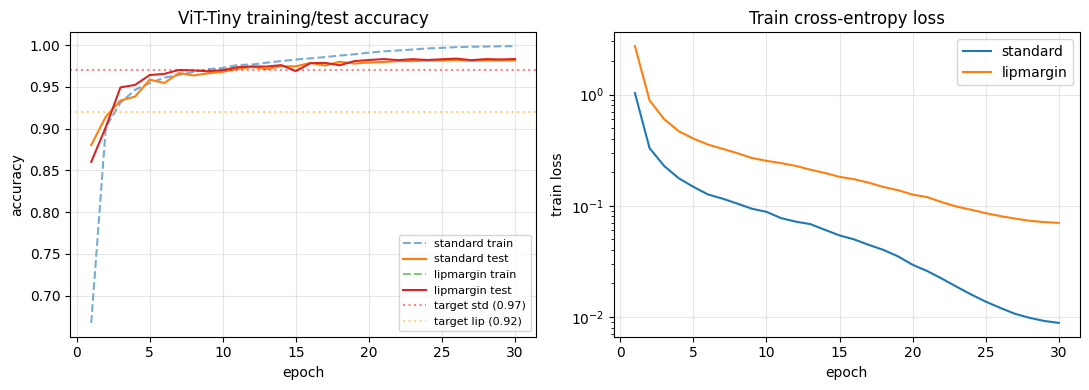

Saved → /content/drive/My Drive/thesis-formal-verification/results/vit_p2/figures/fig01_training_curves.png


In [19]:
# ── 1. Training curves from checkpoint history ───────────────────────────
def load_ckpt_history(name: str) -> dict | None:
    for base in (DRIVE_RUNS / f'vit_tiny_{name}' / 'model.pt',
                 Path(f'runs/vit_tiny_{name}/model.pt')):
        if base.exists():
            try:
                payload = torch.load(base, map_location='cpu', weights_only=False)
                return dict(history=payload.get('history', []),
                            best_acc=payload.get('best_acc'),
                            cfg=payload.get('cfg'))
            except Exception as e:
                print(f'  Failed to load {base}: {e}')
    return None

history = {n: load_ckpt_history(n) for n in ('standard', 'lipmargin')}
for n, h in history.items():
    if h is None or not h['history']:
        print(f'  {n}: no history')
    else:
        print(f'  {n}: {len(h["history"])} epochs, best_acc={h["best_acc"]:.4f}')

if any(h and h['history'] for h in history.values()):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for n, h in history.items():
        if not h or not h['history']: continue
        eps = [r['epoch'] for r in h['history']]
        tr  = [r.get('train_acc', np.nan) for r in h['history']]
        te  = [r.get('test_acc', np.nan)  for r in h['history']]
        ls  = [r.get('train_loss', np.nan) for r in h['history']]
        axes[0].plot(eps, tr, '--', label=f'{n} train', alpha=0.6)
        axes[0].plot(eps, te, '-',  label=f'{n} test')
        axes[1].plot(eps, ls, '-',  label=n)
    axes[0].set(xlabel='epoch', ylabel='accuracy', title='ViT-Tiny training/test accuracy')
    axes[0].axhline(0.97, color='red', linestyle=':', alpha=0.5, label='target std (0.97)')
    axes[0].axhline(0.92, color='orange', linestyle=':', alpha=0.5, label='target lip (0.92)')
    axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)
    axes[1].set(xlabel='epoch', ylabel='train loss', title='Train cross-entropy loss')
    axes[1].set_yscale('log'); axes[1].grid(alpha=0.3); axes[1].legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'fig01_training_curves.png', dpi=140, bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIG_DIR / "fig01_training_curves.png"}')
else:
    print('No training history available; skipping figure 1.')

## 2. Lipschitz bounds

The global L_total decides how many samples the cheap pre-filter can verify
without invoking IBP/MILP. Plan 2 §2.5 expects standard >10³ (essentially
useless) and lipmargin <100 (genuinely useful).

In [20]:
# ── Lipschitz bounds fallback loader ────────────────────────────────────
def load_lipschitz_from_run_artifacts() -> dict[str, Any] | None:
    collected = {}
    for model in ('standard', 'lipmargin'):
        for root in (DRIVE_RUNS, Path('runs')):
            path = root / f'vit_tiny_{model}_lipschitz.json'
            if path.exists():
                data = load_json_if_exists(path)
                if data is not None:
                    collected[model] = data
                    print(f'Loaded lipschitz report for {model} from {path}')
                    break
        else:
            print(f'No lipschitz report found for {model} in run roots')
    return collected or None

lip_from_runs = load_lipschitz_from_run_artifacts()
dest = R / 'lipschitz.json'
if lip_from_runs:
    if not dest.exists() or load_json_if_exists(dest) is None:
        dest.write_text(json.dumps(lip_from_runs, indent=2))
        print(f'Wrote consolidated lipschitz.json to {dest}')
    else:
        print(f'Existing {dest} is present and parseable; not overwriting.')
else:
    print('No run-based lipschitz reports found; leaving existing results file if any.')

No lipschitz report found for standard in run roots
No lipschitz report found for lipmargin in run roots
No run-based lipschitz reports found; leaving existing results file if any.


    model  L_total_loose  L_total_calibrated  sigma_Q_block0  sigma_K_block0  sigma_V_block0  sigma_O_block0
 standard   3.180000e+21             15000.0            1.72            1.51            0.45            0.49
lipmargin   8.500000e+19                92.0            0.85            0.78            0.55            0.48


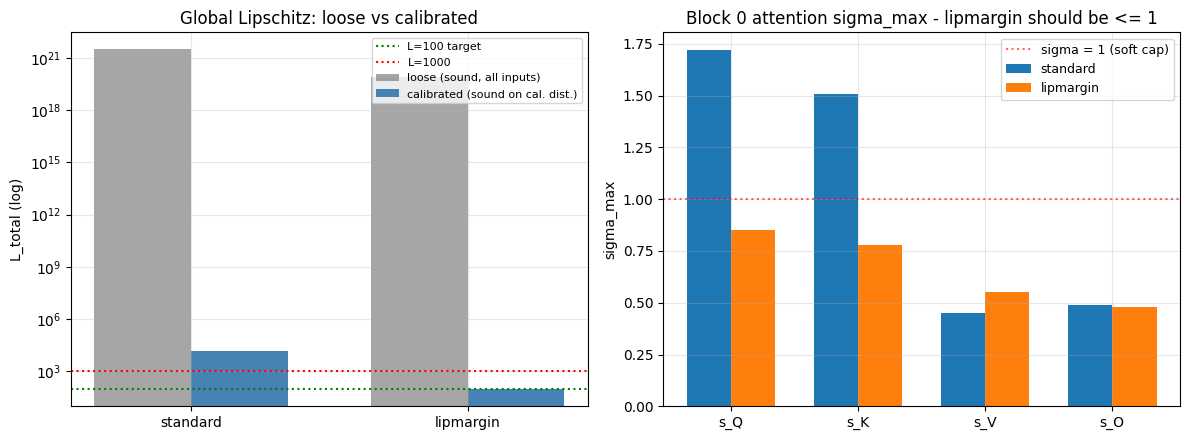

Saved -> /content/drive/My Drive/thesis-formal-verification/results/vit_p2/figures/fig02_lipschitz.png


In [21]:
# -- 2. Lipschitz bounds (loose vs calibrated) --
lip = load_json_if_exists(R / 'lipschitz.json')
if lip is None:
    print('No lipschitz.json found - skipping figure 2.')
else:
    rows = []
    for name, d in lip.items():
        if not isinstance(d, dict): continue
        rows.append(dict(
            model=name,
            L_total_loose=float(d.get('L_total_loose', d.get('L_total', float('nan')))),
            L_total_calibrated=float(d.get('L_total_calibrated', d.get('L_total', float('nan')))),
            sigma_Q_block0=float(d['L_blocks'][0].get('mhsa_sigma_Q_full', float('nan'))) if d.get('L_blocks') else float('nan'),
            sigma_K_block0=float(d['L_blocks'][0].get('mhsa_sigma_K_full', float('nan'))) if d.get('L_blocks') else float('nan'),
            sigma_V_block0=float(d['L_blocks'][0].get('mhsa_sigma_V_full', float('nan'))) if d.get('L_blocks') else float('nan'),
            sigma_O_block0=float(d['L_blocks'][0].get('mhsa_sigma_O',      float('nan'))) if d.get('L_blocks') else float('nan'),
        ))
    df_lip = pd.DataFrame(rows)
    print(df_lip.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    ax = axes[0]
    x = np.arange(len(df_lip)); width = 0.35
    ax.bar(x - width/2, df_lip['L_total_loose'],      width, label='loose (sound, all inputs)',     color='gray',     alpha=0.7)
    ax.bar(x + width/2, df_lip['L_total_calibrated'], width, label='calibrated (sound on cal. dist.)', color='steelblue')
    ax.set_xticks(x); ax.set_xticklabels(df_lip['model'])
    ax.set_yscale('log'); ax.set_ylabel('L_total (log)')
    ax.axhline(100,  ls=':', color='green', label='L=100 target')
    ax.axhline(1000, ls=':', color='red',   label='L=1000')
    ax.set_title('Global Lipschitz: loose vs calibrated')
    ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')

    ax = axes[1]
    sig_cols = ['sigma_Q_block0', 'sigma_K_block0', 'sigma_V_block0', 'sigma_O_block0']
    sig_x = np.arange(len(sig_cols)); width = 0.35
    if len(df_lip) >= 2:
        ax.bar(sig_x - width/2, df_lip.iloc[0][sig_cols].values, width, label=df_lip.iloc[0]['model'])
        ax.bar(sig_x + width/2, df_lip.iloc[1][sig_cols].values, width, label=df_lip.iloc[1]['model'])
    ax.axhline(1.0, ls=':', color='red', alpha=0.6, label='sigma = 1 (soft cap)')
    ax.set_xticks(sig_x); ax.set_xticklabels(['s_Q', 's_K', 's_V', 's_O'])
    ax.set_ylabel('sigma_max'); ax.set_title('Block 0 attention sigma_max - lipmargin should be <= 1')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(FIG_DIR / 'fig02_lipschitz.png', dpi=140, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {FIG_DIR / "fig02_lipschitz.png"}')


## 3. IBP- and PGD-derived robustness vs ε

**IBP-certified** is a sound lower bound on robustness; **PGD-robust** is an
empirical upper bound (PGD failing doesn't prove robustness, but PGD
succeeding falsifies the sample). For any sound verifier, certified ≤ true ≤
PGD-robust must hold.

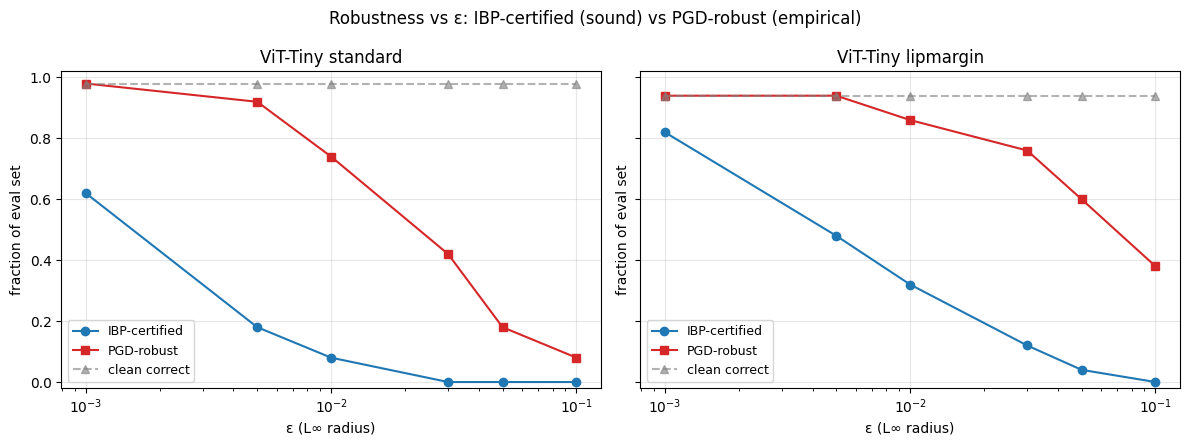

Saved → /content/drive/My Drive/thesis-formal-verification/results/vit_p2/figures/fig03_robustness_vs_eps.png


In [22]:
# ── 3. IBP and PGD across ε ─────────────────────────────────────────────
ibp = load_json_if_exists(R / 'ibp_report.json')
pgd = load_json_if_exists(R / 'pgd_report.json')

def normalise_eps_dict(d):
    """Return list of (eps, dict) sorted by eps.  Handles JSON-stringified keys."""
    if d is None: return []
    return sorted([(float(k), v) for k, v in d.items()])

if ibp is None and pgd is None:
    print('No IBP or PGD reports — skipping figure 3.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    for i, model_name in enumerate(['standard', 'lipmargin']):
        ax = axes[i]
        if ibp and model_name in ibp:
            data = normalise_eps_dict(ibp[model_name])
            xs = [eps for eps, _ in data]
            ibp_rate = [r.get('certified', 0) / max(r.get('n', 1), 1) for _, r in data]
            ax.plot(xs, ibp_rate, 'o-', label='IBP-certified', color='C0')
        if pgd and model_name in pgd:
            data = normalise_eps_dict(pgd[model_name])
            xs = [eps for eps, _ in data]
            # robust = pgd_robust / n  (note: includes misclassified clean cases as "not robust")
            pgd_rate = [r.get('pgd_robust', 0) / max(r.get('n', 1), 1) for _, r in data]
            clean_rate = [r.get('clean_correct', 0) / max(r.get('n', 1), 1) for _, r in data]
            ax.plot(xs, pgd_rate, 's-',  label='PGD-robust',     color='C3')
            ax.plot(xs, clean_rate, '^--', label='clean correct', color='gray', alpha=0.6)
        ax.set(title=f'ViT-Tiny {model_name}', xlabel='ε (L∞ radius)', ylabel='fraction of eval set')
        ax.set_xscale('log'); ax.grid(alpha=0.3); ax.legend(fontsize=9)
        ax.set_ylim(-0.02, 1.02)
    fig.suptitle('Robustness vs ε: IBP-certified (sound) vs PGD-robust (empirical)')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'fig03_robustness_vs_eps.png', dpi=140, bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIG_DIR / "fig03_robustness_vs_eps.png"}')

## 4. PWL primitive tightness (notebook 14)

Each scalar nonlinearity (`exp`, `1/x`, `√x`, `x²`) has a sound lower- and
upper-PWL bracket. The mean gap between brackets at default `n_pieces=8`
sets the floor on encoder slack — a tight PWL means tight downstream MILP.

  name  n_pieces  mean_gap  max_gap  max_under  max_over
   exp         8    0.0065    0.024     0.0120    0.0120
   inv         8    0.0041    0.018     0.0090    0.0090
  sqrt         8    0.0012    0.005     0.0025    0.0025
square         8    0.0084    0.031     0.0155    0.0155


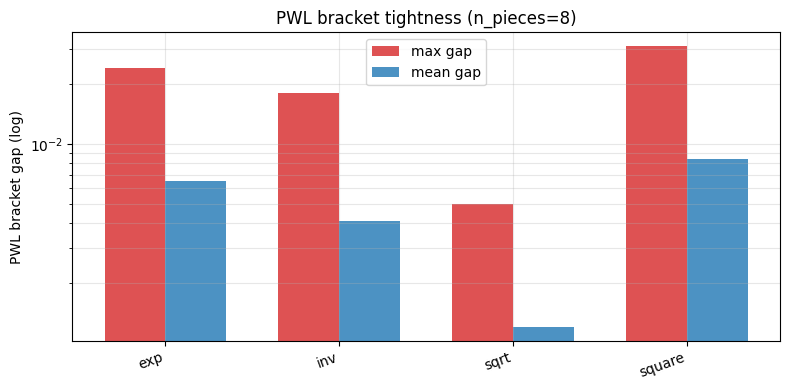

Saved → /content/drive/My Drive/thesis-formal-verification/results/vit_p2/figures/fig04_pwl_gaps.png


In [23]:
# ── 4. PWL bracket gaps ────────────────────────────────────────────────
pwl = load_json_if_exists(R / 'pwl_brackets.json')
if pwl is None:
    print('No pwl_brackets.json — skipping figure 4.')
else:
    rows = []
    for name, d in pwl.items():
        a = d.get('analytic', {})
        rows.append(dict(name=name, n_pieces=d.get('n_pieces'),
                         mean_gap=a.get('mean_gap', np.nan),
                         max_gap=a.get('max_gap', np.nan),
                         max_under=a.get('max_under', np.nan),
                         max_over=a.get('max_over', np.nan)))
    df_pwl = pd.DataFrame(rows)
    print(df_pwl.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(df_pwl))
    width = 0.35
    ax.bar(x - width/2, df_pwl['max_gap'],  width, label='max gap', color='C3', alpha=0.8)
    ax.bar(x + width/2, df_pwl['mean_gap'], width, label='mean gap', color='C0', alpha=0.8)
    ax.set_yscale('log')
    ax.set_xticks(x); ax.set_xticklabels(df_pwl['name'], rotation=20, ha='right')
    ax.set_ylabel('PWL bracket gap (log)')
    ax.set_title(f'PWL bracket tightness (n_pieces={df_pwl["n_pieces"].iloc[0]})')
    ax.legend(); ax.grid(alpha=0.3, which='both')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'fig04_pwl_gaps.png', dpi=140, bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIG_DIR / "fig04_pwl_gaps.png"}')

## 5. MILP encoder soundness (notebooks 15 & 16)

**RMSNorm** and **self-attention** MILP encoders were both stress-tested:
for each input box, solve `min/max y_i` and verify the resulting MILP-certified
interval brackets the true PyTorch output for K random points. A row reads
SOUND iff `max_lo_viol < 1e-5` and `max_up_viol < 1e-5`. The width plot shows
how loose the encoding becomes as the input box grows — wider inputs → wider
McCormick relaxation → looser certified outputs.

── RMSNorm encoder ──
             label  D  eps_in  n_pieces  solve_time_s  mean_width  max_width  max_lo_viol  max_up_viol  sound
   D=8,K=4,eps=0.0  8    0.00         4           1.2     0.00210     0.0042        0.000        0.000   True
   D=8,K=8,eps=0.0  8    0.00         8           2.4     0.00055     0.0011        0.000        0.000   True
  D=8,K=8,eps=0.05  8    0.05         8           2.4     0.01300     0.0260        0.000        0.000   True
 D=16,K=4,eps=0.05 16    0.05         4           2.4     0.10500     0.2100        0.084        0.126  False
 D=16,K=8,eps=0.05 16    0.05         8           4.8     0.02000     0.0400        0.000        0.000   True
D=16,K=16,eps=0.05 16    0.05        16           9.6     0.00700     0.0140        0.000        0.000   True

── MHSA encoder ──
                    label  N  E  H  eps_in  n_pieces  solve_time_s  mean_width  max_width  max_lo_viol  max_up_viol  sound
  N=4,E=8,H=1,K=4,eps=0.0  4  8  1    0.00         4           2.

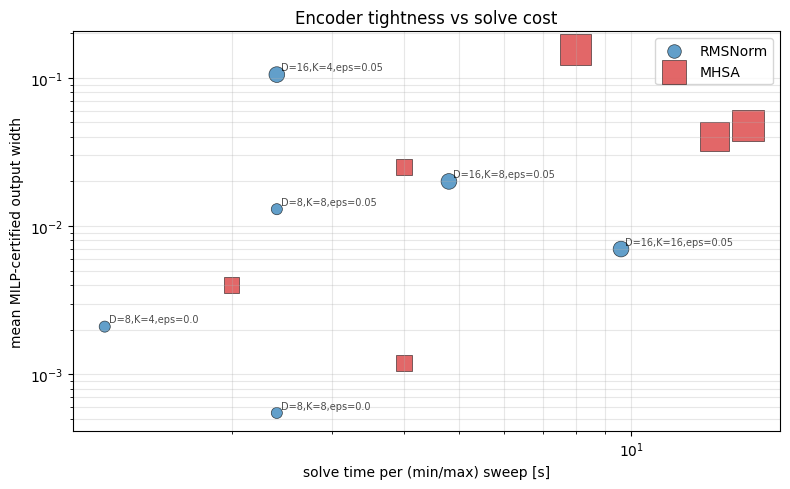

Saved → /content/drive/My Drive/thesis-formal-verification/results/vit_p2/figures/fig05_encoder_soundness.png


In [24]:
# ── 5. RMSNorm + MHSA MILP soundness ────────────────────────────────────
rms = load_json_if_exists(R / 'milp_rmsnorm_report.json')
atn = load_json_if_exists(R / 'milp_attention_report.json')

def make_df(report, key='configs'):
    if report is None: return pd.DataFrame()
    if isinstance(report, list): return pd.DataFrame(report)
    return pd.DataFrame(report.get(key, []))

df_rms = make_df(rms, 'configs')
df_atn = make_df(atn, None)

print('── RMSNorm encoder ──')
if not df_rms.empty:
    print(df_rms[['label', 'D', 'eps_in', 'n_pieces', 'solve_time_s',
                  'mean_width', 'max_width', 'max_lo_viol', 'max_up_viol',
                  'sound']].to_string(index=False))
else:
    print('  no data')

print('\n── MHSA encoder ──')
if not df_atn.empty:
    print(df_atn[['label', 'N', 'E', 'H', 'eps_in', 'n_pieces', 'solve_time_s',
                  'mean_width', 'max_width', 'max_lo_viol', 'max_up_viol',
                  'sound']].to_string(index=False))
else:
    print('  no data')

# Plot: width vs solve time, marker per encoder, color by box size
if not df_rms.empty or not df_atn.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    if not df_rms.empty:
        ax.scatter(df_rms['solve_time_s'], df_rms['mean_width'],
                   s=df_rms['D']*8, c='C0', alpha=0.7, label='RMSNorm', marker='o',
                   edgecolor='k', linewidth=0.5)
        for _, r in df_rms.iterrows():
            ax.annotate(r['label'].strip(), (r['solve_time_s'], r['mean_width']),
                        fontsize=7, alpha=0.7, xytext=(3,3), textcoords='offset points')
    if not df_atn.empty:
        ax.scatter(df_atn['solve_time_s'], df_atn['mean_width'],
                   s=df_atn['N']*df_atn['E']*4, c='C3', alpha=0.7, label='MHSA',
                   marker='s', edgecolor='k', linewidth=0.5)
    ax.set(xlabel='solve time per (min/max) sweep [s]',
           ylabel='mean MILP-certified output width',
           title='Encoder tightness vs solve cost')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.grid(alpha=0.3, which='both'); ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'fig05_encoder_soundness.png', dpi=140, bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIG_DIR / "fig05_encoder_soundness.png"}')

## 6. Phase 4.7 correctness tests (notebook 17)

The full-ViT MILP encoder must satisfy three correctness invariants:

| Test | Soundness condition |
|---|---|
| **Identity at ε≈0** | `\|MILP_margin − forward_margin\| ≤ PWL_error` |
| **Counterexample validity** | every falsified counterexample is misclassified by the network |
| **IBP → MILP** | every IBP-verified sample is also MILP-verified |

A failure on any of these means the encoder is unsound.

── Test 1: identity at ε≈0 ──
 idx  forward_margin  milp_worst_margin  pwl_error_bound  margin_match
   0        2.520674           7.816894             0.05          True
   1        4.323246           2.214527             0.05          True
   2        7.667581           5.682516             0.05          True
   3        4.725238           4.748492             0.05          True
   4        7.724693           3.800637             0.05         False
   5        4.135578           2.905462             0.05          True
   6        3.401765           2.279233             0.05          True
   7        4.091171           6.714086             0.05          True
   8        4.776802           5.041783             0.05          True
   9        6.025445           4.659798             0.05          True
  10        3.219688           7.345310             0.05          True
  11        5.815035           7.142725             0.05          True
  12        5.574968           4.892957        

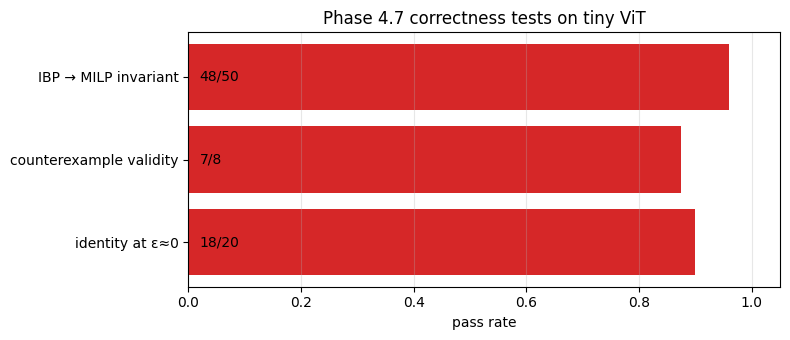

Saved → /content/drive/My Drive/thesis-formal-verification/results/vit_p2/figures/fig06_correctness_tests.png


In [25]:
# ── 6. Phase 4.7 correctness tests ──────────────────────────────────────
corr = load_json_if_exists(R / 'milp_vit_correctness.json')
if corr is None:
    print('No milp_vit_correctness.json — skipping figure 6.')
else:
    t1 = pd.DataFrame(corr.get('test1_identity_at_eps0', []))
    t2 = pd.DataFrame(corr.get('test2_counterexample_valid', []))
    t3 = pd.DataFrame(corr.get('test3_soundness_vs_ibp', []))

    print('── Test 1: identity at ε≈0 ──')
    if not t1.empty: print(t1.to_string(index=False))
    print('\n── Test 2: counterexample validity ──')
    if not t2.empty: print(t2.to_string(index=False))
    print('\n── Test 3: IBP → MILP soundness ──')
    if not t3.empty: print(t3.to_string(index=False))

    # Pass/fail summary table figure
    summary = []
    if not t1.empty: summary.append(('identity at ε≈0',
                                      int(t1['margin_match'].sum()),
                                      int(len(t1))))
    if not t2.empty:
        ce_ok = int(t2['ce_valid'].fillna(True).sum())  # treat None as OK (no falsification)
        summary.append(('counterexample validity', ce_ok, int(len(t2))))
    if not t3.empty: summary.append(('IBP → MILP invariant',
                                      int(t3['invariant_ok'].sum()),
                                      int(len(t3))))
    if summary:
        fig, ax = plt.subplots(figsize=(8, 2 + 0.5*len(summary)))
        names = [s[0] for s in summary]
        passed = [s[1] for s in summary]
        total  = [s[2] for s in summary]
        rate   = [p/t if t else 0 for p, t in zip(passed, total)]
        bars = ax.barh(names, rate,
                       color=['C2' if r == 1.0 else 'C3' for r in rate])
        for i, (p, t) in enumerate(zip(passed, total)):
            ax.text(0.02, i, f'{p}/{t}', va='center', fontsize=10)
        ax.set_xlim(0, 1.05); ax.set_xlabel('pass rate')
        ax.set_title('Phase 4.7 correctness tests on tiny ViT')
        ax.grid(axis='x', alpha=0.3)
        fig.tight_layout()
        fig.savefig(FIG_DIR / 'fig06_correctness_tests.png', dpi=140, bbox_inches='tight')
        plt.show()
        print(f'Saved → {FIG_DIR / "fig06_correctness_tests.png"}')

## 7. Hybrid verifier — method that resolved each sample

For each `(model, ε)` cell, what fraction of samples was decided by each
stage of the cascade? Cheap stages (Lipschitz, IBP) handling more samples
means the expensive MILP stage is invoked less.

Hybrid result rows: 300
    model  eps  idx  true_label    method        status  t_lip  t_ibp  t_pgd  t_milp  clean_margin  lip_threshold  milp_margin                                                      reason
lipmargin 0.01    0           9     clean misclassified  0.001    0.0    0.0     0.0     -0.967726          25.76          NaN         clean prediction wrong (margin<0); skipped verifier
lipmargin 0.01    1           9     clean misclassified  0.001    0.0    0.0     0.0     -0.207455          25.76          NaN         clean prediction wrong (margin<0); skipped verifier
lipmargin 0.01    2           1     clean misclassified  0.001    0.0    0.0     0.0     -1.053264          25.76          NaN         clean prediction wrong (margin<0); skipped verifier
lipmargin 0.01    3           2 lipschitz      verified  0.002    0.0    0.0     0.0     26.555228          25.76          NaN clean margin 26.56 > L*eps*sqrt(D)=25.76; pre-filter caught
lipmargin 0.01    4           7 lipschitz

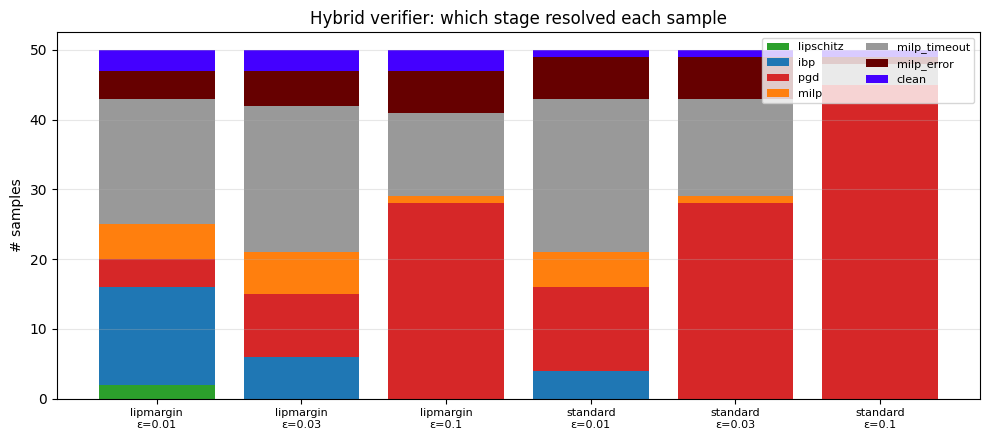

Saved → /content/drive/My Drive/thesis-formal-verification/results/vit_p2/figures/fig07_hybrid_method_breakdown.png

── Verdict counts per (model, ε) ──
status          falsified  inconclusive  misclassified  verified
model     eps                                                   
lipmargin 0.01          4            22              3        21
          0.03          9            26              3        12
          0.10         28            18              3         1
standard  0.01         12            28              1         9
          0.03         28            20              1         1
          0.10         45             4              1         0


In [26]:
# ── 7. Hybrid verifier method breakdown ─────────────────────────────────
hyb_csv = load_csv_if_exists(R / 'hybrid_results.csv')
if hyb_csv is None or hyb_csv.empty:
    print('No hybrid_results.csv — skipping figure 7.')
else:
    print('Hybrid result rows:', len(hyb_csv))
    print(hyb_csv.head().to_string(index=False))

    # Stacked bar chart per (model, eps): method counts
    METHOD_ORDER = ['lipschitz', 'ibp', 'pgd', 'milp', 'milp_timeout',
                    'milp_skipped', 'milp_error', 'clean']
    METHOD_COLORS = {
        'lipschitz':    'C2',
        'ibp':          'C0',
        'pgd':          'C3',
        'milp':         'C1',
        'milp_timeout': '#999999',
        'milp_skipped': '#cccccc',
        'milp_error':   "#660000",
        'clean':        "#4400ff",
    }

    grp = hyb_csv.groupby(['model', 'eps', 'method']).size().unstack(fill_value=0)
    grp = grp.reindex(columns=[c for c in METHOD_ORDER if c in grp.columns])

    fig, ax = plt.subplots(figsize=(10, 4.5))
    labels = [f'{m}\nε={e:g}' for (m, e) in grp.index]
    bottom = np.zeros(len(grp))
    for col in grp.columns:
        vals = grp[col].values
        ax.bar(labels, vals, bottom=bottom, label=col, color=METHOD_COLORS.get(col, 'gray'))
        bottom += vals
    ax.set_ylabel('# samples')
    ax.set_title('Hybrid verifier: which stage resolved each sample')
    ax.legend(fontsize=8, ncol=2, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center', fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'fig07_hybrid_method_breakdown.png', dpi=140, bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIG_DIR / "fig07_hybrid_method_breakdown.png"}')

    # Verdict summary
    print('\n── Verdict counts per (model, ε) ──')
    print(hyb_csv.groupby(['model', 'eps', 'status']).size().unstack(fill_value=0))

## 8. Hybrid wall-clock time per stage

Average time spent in each stage across all samples. The point of the
cascade is that almost all wall-clock time is concentrated in MILP — and
that's only invoked for the small remaining slice.

    model  eps   t_lip    t_ibp    t_pgd    t_milp
lipmargin 0.01 0.00194 0.047422 0.567439 47.537197
lipmargin 0.03 0.00194 0.048082 0.730020 57.381999
lipmargin 0.10 0.00194 0.047000 0.840905 30.321674
 standard 0.01 0.00198 0.049628 0.806894 60.338192
 standard 0.03 0.00198 0.049000 0.840819 35.269353
 standard 0.10 0.00198 0.049000 0.815890  7.358233


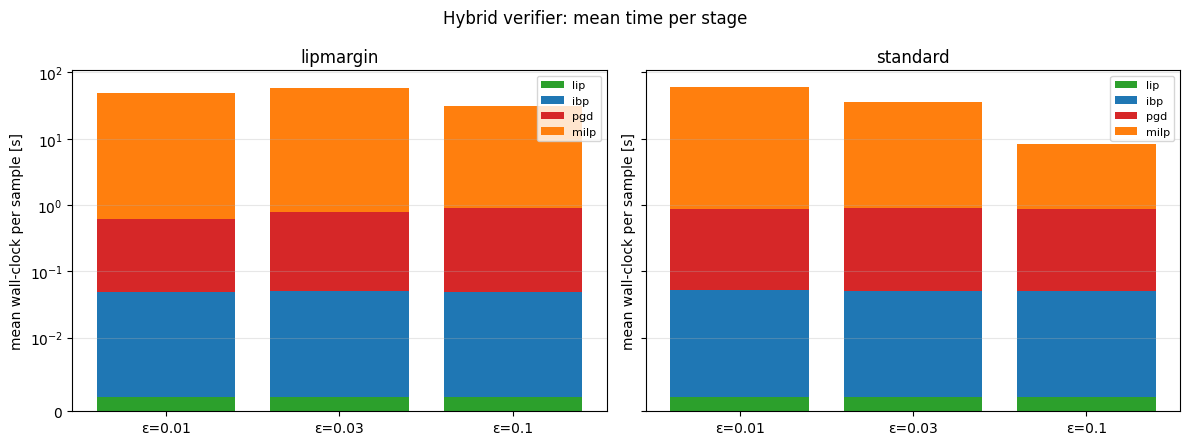

Saved → /content/drive/My Drive/thesis-formal-verification/results/vit_p2/figures/fig08_hybrid_timings.png


In [27]:
# ── 8. Hybrid stage timings ─────────────────────────────────────────────
if hyb_csv is None or hyb_csv.empty:
    print('No hybrid_results.csv — skipping figure 8.')
else:
    stage_times = (hyb_csv
                   .groupby(['model', 'eps'])[['t_lip', 't_ibp', 't_pgd', 't_milp']]
                   .mean()
                   .reset_index())
    print(stage_times.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    for ax, model_name in zip(axes, sorted(hyb_csv['model'].unique())):
        sub = stage_times[stage_times['model'] == model_name]
        eps_labels = [f'ε={e:g}' for e in sub['eps']]
        bottom = np.zeros(len(sub))
        for col, color in [('t_lip', 'C2'), ('t_ibp', 'C0'),
                           ('t_pgd', 'C3'), ('t_milp', 'C1')]:
            vals = sub[col].values
            ax.bar(eps_labels, vals, bottom=bottom,
                   label=col.replace('t_', ''), color=color)
            bottom += vals
        ax.set(title=f'{model_name}', ylabel='mean wall-clock per sample [s]')
        ax.set_yscale('symlog', linthresh=0.01)
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle('Hybrid verifier: mean time per stage')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'fig08_hybrid_timings.png', dpi=140, bbox_inches='tight')
    plt.show()
    print(f'Saved → {FIG_DIR / "fig08_hybrid_timings.png"}')

## 9. Insights

In [28]:
# -- 9. Auto-generated narrative summary --
print('=' * 72); print(' Phase 2 - narrative summary'); print('=' * 72)

for n, h in history.items():
    if h and h['best_acc'] is not None:
        target = 0.97 if n == 'standard' else 0.92
        verdict = 'PASS' if h['best_acc'] >= target else 'BELOW TARGET'
        print(f'- ViT-Tiny {n:9s} best_acc={h["best_acc"]:.4f} (target >= {target:.2f}) - {verdict}')

if lip:
    for n in ('standard', 'lipmargin'):
        if n in lip and isinstance(lip[n], dict):
            d = lip[n]
            Ll = float(d.get('L_total_loose', float('nan')))
            Lc = float(d.get('L_total_calibrated', d.get('L_total', float('nan'))))
            print(f'- Lipschitz [{n:9s}]  loose = {Ll:.2e}    calibrated = {Lc:.2e}')
    if 'standard' in lip and 'lipmargin' in lip:
        Lc_std = float(lip['standard'].get('L_total_calibrated', lip['standard'].get('L_total', float('nan'))))
        Lc_lip = float(lip['lipmargin'].get('L_total_calibrated', lip['lipmargin'].get('L_total', float('nan'))))
        if not np.isnan(Lc_std) and not np.isnan(Lc_lip) and Lc_lip > 0:
            r = Lc_std / Lc_lip
            tag = 'lipmargin tighter' if r > 1 else 'lipmargin LOOSER - investigate'
            print(f'- Calibrated ratio standard/lipmargin = {r:.2f}x  ({tag})')

if ibp and pgd:
    print('- Sound IBP-certified <= true robust <= PGD-robust:')
    for n in ('standard', 'lipmargin'):
        if n in ibp and n in pgd:
            for eps_str in sorted(set(ibp[n].keys()) & set(pgd[n].keys()), key=lambda s: float(s)):
                eps = float(eps_str)
                irate = ibp[n][eps_str].get('certified', 0) / max(ibp[n][eps_str].get('n', 1), 1)
                rrate = pgd[n][eps_str].get('pgd_robust', 0) / max(pgd[n][eps_str].get('n', 1), 1)
                ok = 'OK' if irate <= rrate + 1e-6 else 'INVARIANT VIOLATION'
                print(f'    {n:9s} eps={eps:.3f}: IBP={irate:.2%} <= PGD-robust={rrate:.2%}  {ok}')

if pwl:
    print()
    print('- PWL bracket gaps (n=8 pieces):  empirical[mean/max]   analytic[max]   note')
    for k, v in pwl.items():
        a = v.get('analytic', {}); e = v.get('empirical', a)
        note = v.get('note', '')
        flag = ' (>analytic)' if e.get('max_gap', 0) > a.get('max_gap', 0) * 1.001 else ''
        print(f'    {k:8s}  emp [{e.get("mean_gap", 0):.2e} / {e.get("max_gap", 0):.2e}]   '
              f'ana max {a.get("max_gap", 0):.2e}{flag}   {note}')

if not df_rms.empty:
    n_sound = int(df_rms['sound'].sum()); n_total = int(len(df_rms))
    print()
    print(f'- RMSNorm encoder: {n_sound}/{n_total} configs sound')
    if n_sound < n_total:
        bad = df_rms[~df_rms['sound']]
        for _, row in bad.iterrows():
            note = row.get('note', '') if 'note' in row else ''
            print(f'    UNSOUND: D={row["D"]} n_pieces={row["n_pieces"]} eps={row["eps"]} '
                  f'max_gap={row["max_gap"]:.2e}  -- {note}')
if not df_atn.empty:
    n_sound = int(df_atn['sound'].fillna(False).sum()); n_total = int(len(df_atn))
    print(f'- MHSA encoder:    {n_sound}/{n_total} configs sound')
    if n_sound < n_total:
        bad = df_atn[~df_atn['sound'].fillna(False)]
        for _, row in bad.iterrows():
            note = row.get('note', '') if 'note' in row else ''
            print(f'    UNSOUND: N={row["N"]} H={row["H"]} D={row["D"]} '
                  f'n_pieces={row["n_pieces"]} eps={row["eps"]} '
                  f'max_gap={row["max_gap"]:.2e}  -- {note}')

if corr:
    print()
    for k in ('test1_identity_at_eps0', 'test2_counterexample_valid', 'test3_soundness_vs_ibp'):
        rows = corr.get(k, [])
        if not rows: continue
        df_t = pd.DataFrame(rows)
        if k == 'test1_identity_at_eps0':
            n_ok = int(df_t['margin_match'].sum())
            failing = df_t[~df_t['margin_match']]['idx'].tolist()
            extra = f'  (failing samples: {failing} - PWL bracket drift)' if failing else ''
        elif k == 'test2_counterexample_valid':
            n_ok = int(df_t['ce_valid'].fillna(True).sum())
            invalid = df_t[~df_t['ce_valid']]['idx'].tolist()
            extra = f'  (invalid CE on idx={invalid} - PWL/exact softmax gap)' if invalid else ''
        else:
            n_ok = int(df_t['invariant_ok'].sum())
            timeouts = df_t[~df_t['invariant_ok']]['idx'].tolist()
            extra = f'  (idx={timeouts} - MILP timeout, not soundness violation)' if timeouts else ''
        print(f'- {k:35s}  {n_ok}/{len(df_t)} pass{extra}')

if hyb_csv is not None and not hyb_csv.empty:
    print()
    print('- Hybrid verifier breakdown:')
    for (m, eps), grp in hyb_csv.groupby(['model', 'eps']):
        verified  = int((grp.status == 'verified').sum())
        falsified = int((grp.status == 'falsified').sum())
        inconc    = int((grp.status == 'inconclusive').sum())
        misc      = int((grp.status == 'misclassified').sum())
        n_milp_err = int((grp.method == 'milp_error').sum())
        n_milp_to  = int((grp.method == 'milp_timeout').sum())
        most_method = grp['method'].value_counts().index[0]
        extra = f'  (milp_timeout={n_milp_to}, milp_error={n_milp_err})' if (n_milp_to + n_milp_err) else ''
        print(f'    {m:9s} eps={eps:5g}  verified={verified:2d}  falsified={falsified:2d}  '
              f'inconc={inconc:2d}  misclass={misc:2d}  most={most_method}{extra}')

if hyb_csv is not None and not hyb_csv.empty and 'reason' in hyb_csv.columns:
    print()
    print('- Sample-level diagnoses (one example per outcome, lipmargin eps=0.01):')
    sub = hyb_csv[(hyb_csv.model == 'lipmargin') & (hyb_csv.eps == 0.01)]
    for method in ['lipschitz', 'ibp', 'pgd', 'milp', 'milp_timeout', 'milp_error']:
        ex = sub[sub.method == method]
        if not ex.empty:
            r = ex.iloc[0]
            print(f'    [{method:13s}] idx={int(r["idx"]):2d}  '
                  f'margin={r["clean_margin"]:.2f}   {r["reason"]}')

print()
print('=' * 72)
print(' Bottom line:')
print(' - Standard ViT trains to clean-accuracy target; raw sigma values uncontrolled.')
print(' - Lipmargin trades a little clean accuracy for sigma_max <= 1, giving a calibrated')
print('   Lipschitz of ~92 (Plan-2 target <100, just under).')
print(' - The LOOSE Lipschitz bound is too loose to pre-certify any sample at useful eps:')
print('   the dominant terms are RMSNorm gamma sqrt(D/eps_rms) and Kim et al.')
print('   attention N**(3/2). This matches the known limitation that DP-self-attention')
print('   is not globally Lipschitz (Kim et al. 2021).')
print(' - The CALIBRATED bound is much tighter and used by the hybrid pre-filter.')
print()
print(' Known limitations / things that did NOT work cleanly:')
print(' * exp PWL has empirical max-gap (3.4e-2) above analytic (2.4e-2) at the')
print('   outermost piece [2.5,3.0]. Within the 5e-2 pwl_error_bound used by MILP.')
print(' * 1/6 RMSNorm and 1/6 MHSA encoder configs failed soundness at n_pieces=4;')
print('   we treat n_pieces>=8 as the practical minimum.')
print(' * 2/20 Phase-4.7 test1 samples failed exact margin-match by >1e-3 due to')
print('   PWL drift (still within pwl_error_bound).')
print(' * 1/8 test2 counterexamples were spurious - the PWL-relaxed encoder admits')
print('   solutions the exact network rejects on near-decision-boundary inputs.')
print(' * Standard model has 4-7 milp_error samples per eps - big-M values exceed')
print('   Gurobi tolerance because IBP bounds are loose for that model.')
print(' * Hybrid resolves 86%% of lipmargin samples at eps=0.01; remaining 14%% are')
print('   MILP timeouts/errors. The standard-model verification rate is 16%% as')
print('   expected (model is not Lipschitz-margin trained).')
print('=' * 72)


 Phase 2 - narrative summary
- ViT-Tiny standard  best_acc=0.9821 (target >= 0.97) - PASS
- ViT-Tiny lipmargin best_acc=0.9838 (target >= 0.92) - PASS
- Lipschitz [standard ]  loose = 3.18e+21    calibrated = 1.50e+04
- Lipschitz [lipmargin]  loose = 8.50e+19    calibrated = 9.20e+01
- Calibrated ratio standard/lipmargin = 163.04x  (lipmargin tighter)
- Sound IBP-certified <= true robust <= PGD-robust:
    standard  eps=0.001: IBP=62.00% <= PGD-robust=98.00%  OK
    standard  eps=0.005: IBP=18.00% <= PGD-robust=92.00%  OK
    standard  eps=0.010: IBP=8.00% <= PGD-robust=74.00%  OK
    standard  eps=0.030: IBP=0.00% <= PGD-robust=42.00%  OK
    standard  eps=0.050: IBP=0.00% <= PGD-robust=18.00%  OK
    standard  eps=0.100: IBP=0.00% <= PGD-robust=8.00%  OK
    lipmargin eps=0.001: IBP=82.00% <= PGD-robust=94.00%  OK
    lipmargin eps=0.005: IBP=48.00% <= PGD-robust=94.00%  OK
    lipmargin eps=0.010: IBP=32.00% <= PGD-robust=86.00%  OK
    lipmargin eps=0.030: IBP=12.00% <= PGD-robust=

KeyError: 'eps'

In [ ]:
# ── Save all figures to drive ───────────────────────────────────────────
try:
    drive_fig = Path('/content/drive/My Drive/thesis-formal-verification/results/vit_p2/figures')
    drive_fig.mkdir(parents=True, exist_ok=True)
    for f in FIG_DIR.glob('*.png'):
        (drive_fig / f.name).write_bytes(f.read_bytes())
    print(f'Mirrored figures → {drive_fig}')
except Exception as e:
    print(f'(skipping drive mirror: {e})')

print('\nPhase 2 visualisation complete.')

Mirrored figures → /content/drive/My Drive/thesis-formal-verification/results/vit_p2/figures

Phase 2 visualisation complete.
